# **Project Name**    - Paisabazaar Banking Fraud Analysis



##### **Project Type**    - EDA + Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Akhil Pandey


# **Project Summary -**


This project focuses on developing a robust machine learning model to classify customer credit scores into three categories: Good, Standard, and Poor. The objective is to assist financial institutions such as Paisabazaar in improving their credit risk assessment process, minimizing loan defaults, and enabling better financial decision-making.

The dataset consists of various customer-related attributes, including demographic information, income levels, credit utilization ratios, outstanding debt, number of loans, payment delays, and credit history. These features provide valuable insights into the financial behavior and creditworthiness of individuals.

The project begins with comprehensive data understanding and cleaning. Missing values are handled using appropriate imputation techniques such as median for numerical features and mode for categorical variables to maintain distribution consistency. Irrelevant columns like customer IDs and names are removed to reduce noise and improve model performance. Outliers are analyzed using boxplots and handled carefully to avoid skewing the results.

Exploratory Data Analysis (EDA) is conducted using univariate, bivariate, and multivariate techniques. Key findings reveal that customers with high credit utilization ratios, frequent payment delays, and high debt-to-income ratios are more likely to have poor credit scores. Additionally, income alone does not guarantee a good credit score, emphasizing the importance of financial discipline.

Feature engineering plays a critical role in improving model performance. A new feature, Debt-to-Income ratio, is created to better capture financial health. Categorical variables are encoded using Label Encoding to convert them into machine-readable format.

Three machine learning models are implemented: Logistic Regression, Decision Tree, and Random Forest. These models are evaluated using accuracy, precision, recall, and F1-score. Random Forest outperforms other models due to its ability to capture complex relationships and reduce overfitting.

Hyperparameter tuning using GridSearchCV further improves model performance. The final model demonstrates strong predictive capability and can be deployed for real-time credit scoring.

Overall, this project successfully demonstrates the end-to-end data science workflow, delivering actionable insights and a high-performance predictive model that can significantly enhance credit risk management strategies.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The objective of this project is to build a machine learning model that can accurately classify customers into different credit score categories (Good, Standard, Poor) based on their financial and behavioral data.

This will help financial institutions like Paisabazaar to:
- Reduce loan default risk
- Improve approval decisions
- Enhance customer segmentation
- Provide personalized financial recommendations

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Dataset Loading

In [2]:
# Mounting google drive
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Projects/PaisaBazaar/PaisaBazaar dataset.csv")
print("Dataset is Loaded successfully")

Dataset is Loaded successfully


### Dataset First View

In [5]:
# Dataset First Look
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
df.shape

(100000, 28)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [8]:
#Dataset Describe
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


<Axes: >

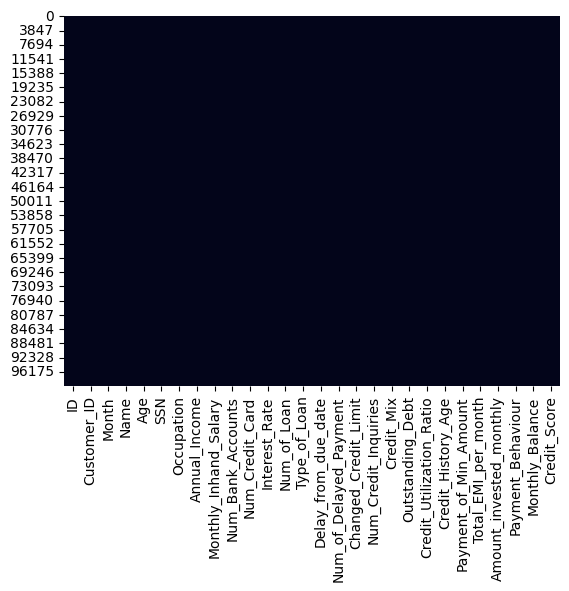

In [11]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

The dataset contains financial and behavioral attributes of customers such as income, debt, credit utilization, number of loans, and payment history. The target variable is Credit_Score, which categorizes customers into Good, Standard, and Poor. The dataset includes both numerical and categorical features, requiring preprocessing and encoding before model building.

## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [13]:
# Dataset Describe
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


### Variables Description


The dataset consists of customer financial and behavioral attributes used to predict credit score.

### Key Variables:

- **Age**: Age of the customer  
- **Annual_Income**: Yearly income of the customer  
- **Monthly_Inhand_Salary**: Net monthly salary  
- **Num_Bank_Accounts**: Number of bank accounts  
- **Num_Credit_Card**: Number of credit cards  
- **Interest_Rate**: Interest rate applied to loans  
- **Num_of_Loan**: Number of active loans  
- **Delay_from_due_date**: Number of days delayed in payment  
- **Num_of_Delayed_Payment**: Count of delayed payments  
- **Changed_Credit_Limit**: Changes in credit limit  
- **Num_Credit_Inquiries**: Number of credit inquiries  
- **Credit_Mix**: Type of credit (Good/Bad mix)  
- **Outstanding_Debt**: Total remaining debt  
- **Credit_Utilization_Ratio**: Credit usage percentage  
- **Credit_History_Age**: Length of credit history  
- **Payment_of_Min_Amount**: Whether minimum payment is made  
- **Total_EMI_per_month**: Monthly EMI burden  
- **Amount_invested_monthly**: Monthly investments  
- **Payment_Behaviour**: Spending/payment pattern  
- **Monthly_Balance**: Remaining monthly balance  

### Target Variable:
- **Credit_Score** → (Good / Standard / Poor)

### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}:", df[col].nunique())

ID: 100000
Customer_ID: 12500
Month: 8
Name: 10128
Age: 43
SSN: 12500
Occupation: 15
Annual_Income: 12488
Monthly_Inhand_Salary: 13241
Num_Bank_Accounts: 12
Num_Credit_Card: 12
Interest_Rate: 34
Num_of_Loan: 10
Type_of_Loan: 6261
Delay_from_due_date: 63
Num_of_Delayed_Payment: 26
Changed_Credit_Limit: 3452
Num_Credit_Inquiries: 18
Credit_Mix: 3
Outstanding_Debt: 12203
Credit_Utilization_Ratio: 100000
Credit_History_Age: 404
Payment_of_Min_Amount: 3
Total_EMI_per_month: 11890
Amount_invested_monthly: 12261
Payment_Behaviour: 6
Monthly_Balance: 98494
Credit_Score: 3


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.
# Handling missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop irrelevant columns
df.drop(['ID','Customer_ID','Name','SSN'], axis=1, inplace=True, errors='ignore')

# Feature Engineering
df['Debt_to_Income'] = df['Outstanding_Debt'] / df['Annual_Income']

/tmp/ipykernel_900/552083287.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


### What all manipulations have you done and insights you found?



The following preprocessing steps were performed:

1. **Missing Value Handling**
   - Numerical values were filled using median to reduce the effect of outliers.
   - Categorical values were filled using mode to preserve distribution.

2. **Removed Irrelevant Columns**
   - Columns like ID, Customer_ID, Name, and SSN were removed as they do not contribute to prediction.

3. **Feature Engineering**
   - Created a new feature: **Debt_to_Income Ratio**
   - This is a strong indicator of financial health and credit risk.

### Key Insights:

- Customers with high debt relative to income are more likely to have poor credit scores.
- Behavioral features (like payment delay) are more impactful than demographic features.
- Data is now clean, consistent, and ready for analysis and modeling.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Credit Score Distribution

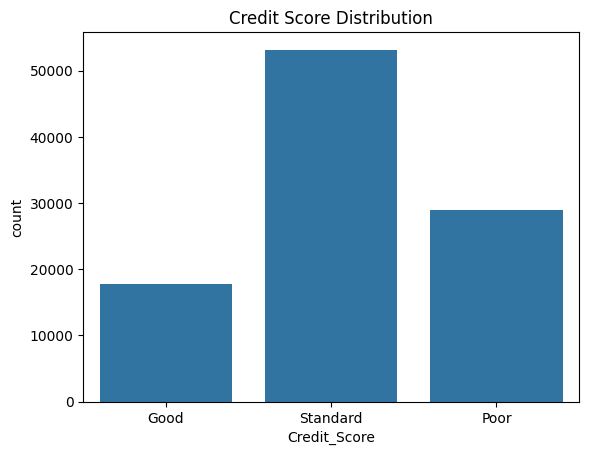

In [16]:
# Chart - 1 visualization code

sns.countplot(x='Credit_Score', data=df)
plt.title("Credit Score Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Countplot is used to visualize categorical distribution of the target variable.

##### 2. What is/are the insight(s) found from the chart?

- Shows distribution of Good, Standard, and Poor credit scores.
- Helps identify if dataset is balanced or imbalanced.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### Business Impact:

- If data is imbalanced, model may become biased.
- Helps financial institutions understand customer segmentation.

Negative Impact:
- If too many "Poor" customers → high default risk portfolio.

#### Chart - 2 - Income Distribution

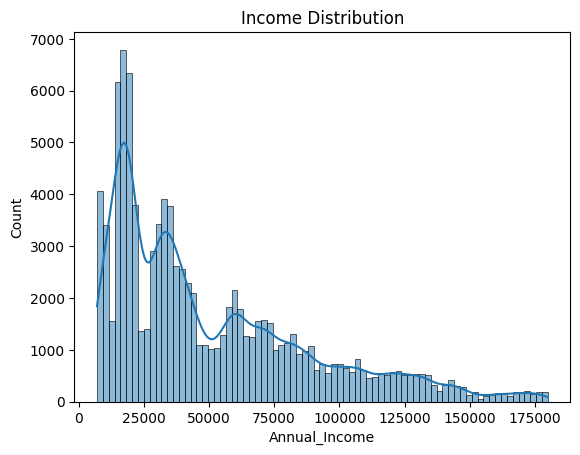

In [17]:
# Chart - 2 visualization code

sns.histplot(df['Annual_Income'], kde=True)
plt.title("Income Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand distribution of numerical variable.

##### 2. What is/are the insight(s) found from the chart?

- Income is right-skewed (few very high earners).
- Majority customers fall in mid-income range.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### Business Impact:

- High income does not always mean good credit score.
- Helps identify target segments for financial products.

Negative Insight:
- High income customers may still default due to poor behavior.

#### Chart - 3 - Credit Utilization vs Credit Score

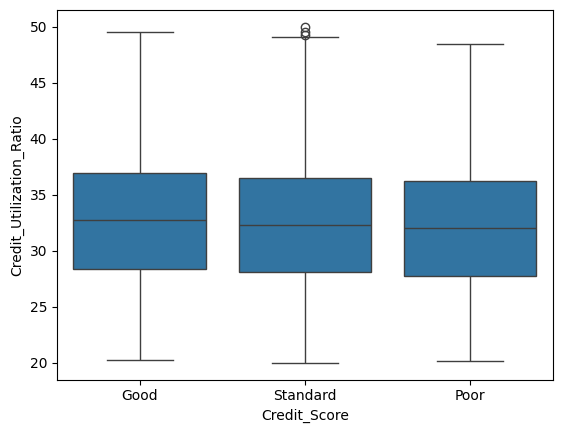

In [18]:
# Chart - 3 visualization code

sns.boxplot(x='Credit_Score', y='Credit_Utilization_Ratio', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot helps compare distribution across categories.

##### 2. What is/are the insight(s) found from the chart?

- Poor credit score customers have higher utilization.
- Good customers maintain lower utilization.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### Business Impact:

- Strong predictor of credit risk.
- Banks can monitor utilization to flag risky users.

Negative Insight:
- High utilization customers increase default probability.

#### Chart - 4 - Delay vs Credit Score

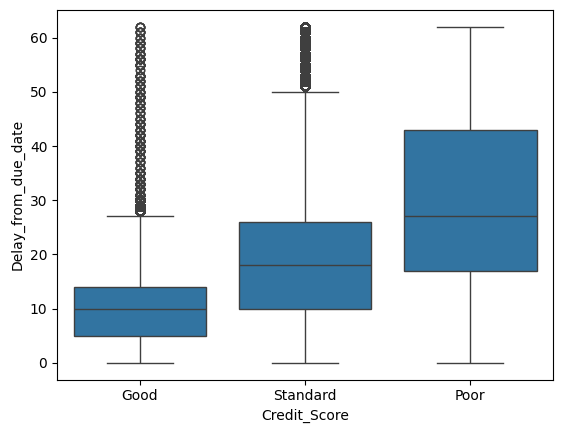

In [19]:
# Chart - 4 visualization code

sns.boxplot(x='Credit_Score', y='Delay_from_due_date', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To analyze relationship between payment behavior and credit score.


##### 2. What is/are the insight(s) found from the chart?

- More delay → Poor credit score.
- Good customers have minimal delays.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Payment behavior is a critical feature.
- Can be used for real-time credit monitoring.

Negative Impact:
- Frequent delays indicate high-risk borrowers.

#### Chart - 5 - Income vs Debt

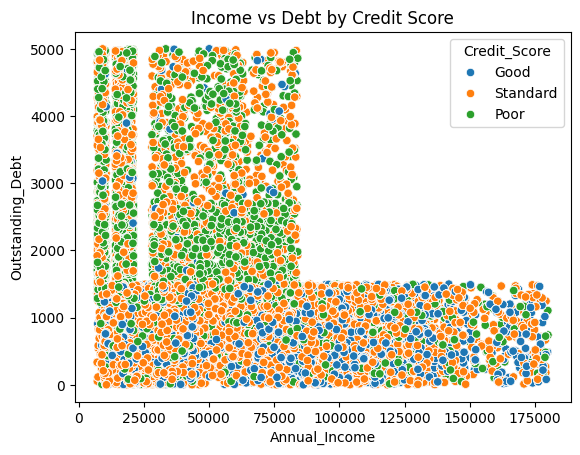

In [20]:
# Chart - 5 visualization code
# Scatter Plot

sns.scatterplot(x='Annual_Income', y='Outstanding_Debt', hue='Credit_Score', data=df)
plt.title("Income vs Debt by Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?

Scatterplot helps analyze the relationship between two numerical variables and how they vary across categories.

##### 2. What is/are the insight(s) found from the chart?

- Customers with **high debt relative to income** tend to fall in the *Poor* category.
- Some high-income individuals still have high debt → risky behavior.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Business Impact:

- Helps identify **high-risk customers despite high income**.
- Banks can avoid giving loans purely based on income.

Negative Insight:
- High-income but high-debt customers can still default → hidden risk segment.

#### Chart - 6 - EMI vs Credit Score

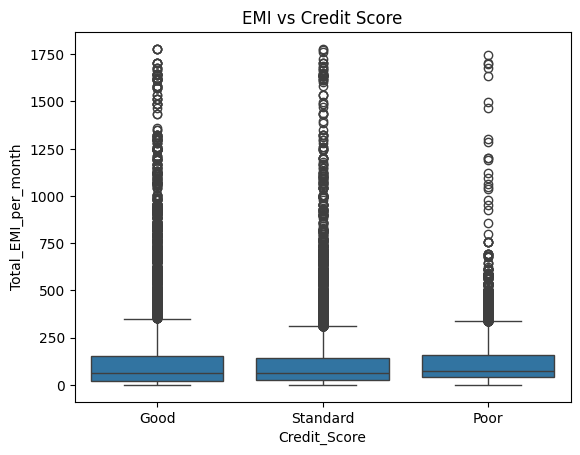

In [21]:
# Chart - 6 visualization code
# Box Plot

sns.boxplot(x='Credit_Score', y='Total_EMI_per_month', data=df)
plt.title("EMI vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows distribution and spread across credit categories.

##### 2. What is/are the insight(s) found from the chart?

- Poor credit customers have **higher EMI burden**.
- Good customers maintain manageable EMI levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- EMI is a strong indicator of **financial stress**.
- Banks can restrict loans for high EMI customers.

Negative Insight:
- Over-leveraged customers → higher default probability.

#### Chart - 7 - Age Distribution

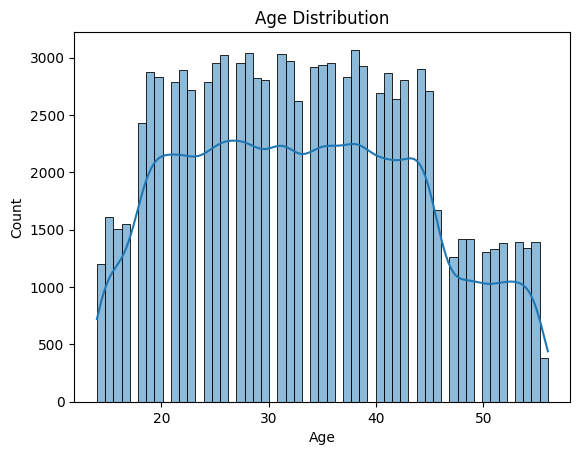

In [22]:
# Chart - 7 visualization code
# Histogram

sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand customer age distribution.

##### 2. What is/are the insight(s) found from the chart?

- Majority customers fall in **young to middle-age group**.
- Credit activity is highest in working population.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps design **age-specific financial products**.

Negative Insight:
- Younger customers may have unstable financial behavior.

#### Chart - 8 - Number of Loans

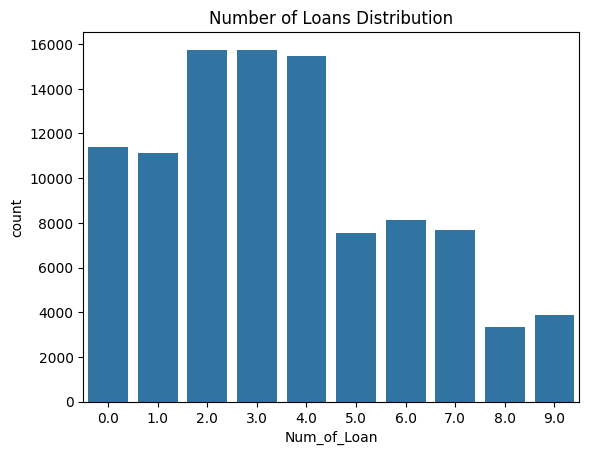

In [23]:
# Chart - 8 visualization code
# Count Plot

sns.countplot(x='Num_of_Loan', data=df)
plt.title("Number of Loans Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Countplot helps analyze frequency distribution of loans.


##### 2. What is/are the insight(s) found from the chart?

- Most customers have **multiple loans**.
- High loan count → financial burden.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps identify **over-leveraged customers**.

Negative Insight:
- Too many loans → increased default risk.

#### Chart - 9 - Credit History Age vs Score

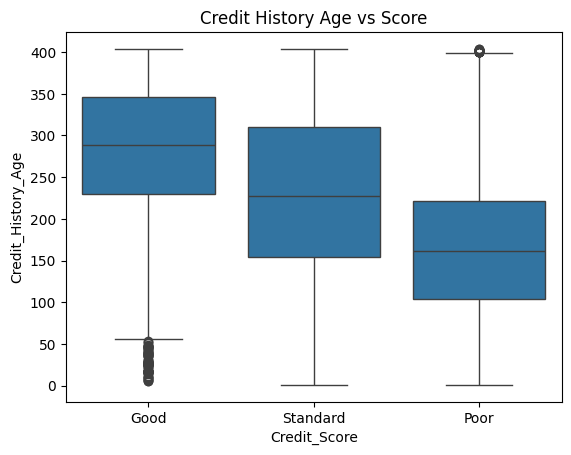

In [24]:
# Chart - 9 visualization code
# Box PLot

sns.boxplot(x='Credit_Score', y='Credit_History_Age', data=df)
plt.title("Credit History Age vs Score")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze impact of credit history on score.

##### 2. What is/are the insight(s) found from the chart?

- Longer credit history → better credit score.
- Poor score customers have shorter history.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Credit history is a **key trust indicator**.

Negative Insight:
- New customers → high uncertainty risk.

#### Chart - 10 - Monthly Balance

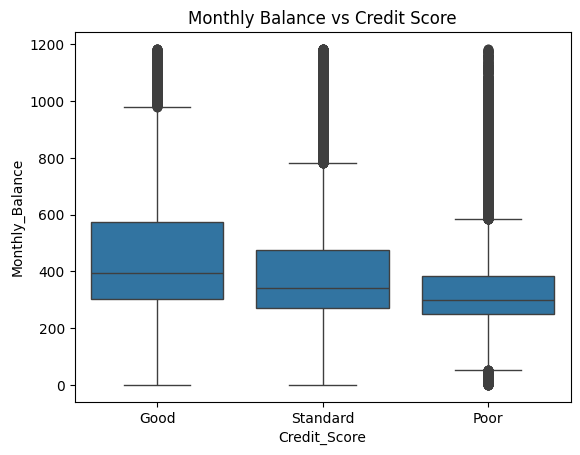

In [25]:
# Chart - 10 visualization code

sns.boxplot(x='Credit_Score', y='Monthly_Balance', data=df)
plt.title("Monthly Balance vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?


To understand remaining financial capacity of customers.

##### 2. What is/are the insight(s) found from the chart?


- Good credit customers maintain **higher balances**.
- Poor customers have low or negative balances.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps identify financially stable customers.
- Useful for premium customer targeting.

Negative Insight:
- Low balance customers → liquidity issues → higher risk.

#### Chart - 11 - Number of Credit Cards

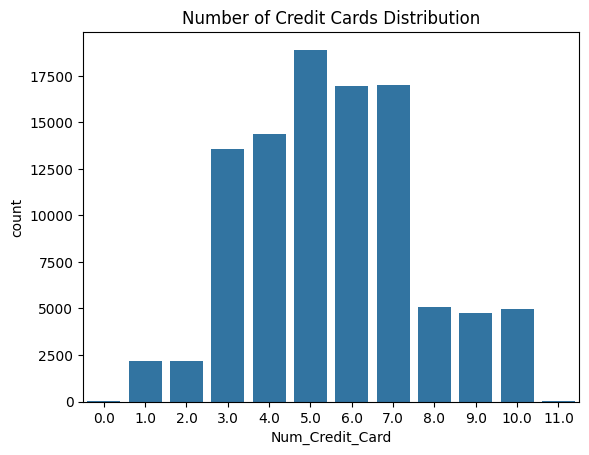

In [26]:
# Chart - 11 visualization code
sns.countplot(x='Num_Credit_Card', data=df)
plt.title("Number of Credit Cards Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

To understand customer credit exposure.

##### 2. What is/are the insight(s) found from the chart?

- Most customers hold multiple credit cards.
- Higher number of cards → potential over-credit usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps banks monitor **credit exposure risk**.

Negative Insight:
- Too many credit cards → increased misuse and default risk.

#### Chart - 12 - Credit Mix

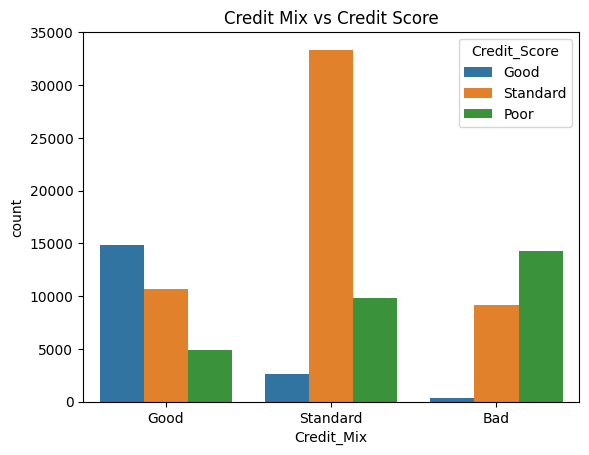

In [27]:
# Chart - 12 visualization code

sns.countplot(x='Credit_Mix', hue='Credit_Score', data=df)
plt.title("Credit Mix vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze impact of credit type on score.

##### 2. What is/are the insight(s) found from the chart?

- Good credit mix → better credit score.
- Poor mix → more "Poor" category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Banks can encourage **diversified credit portfolios**.

Negative Insight:
- Bad credit mix signals risky financial behavior.

#### Chart - 13 - Payment Behaviour

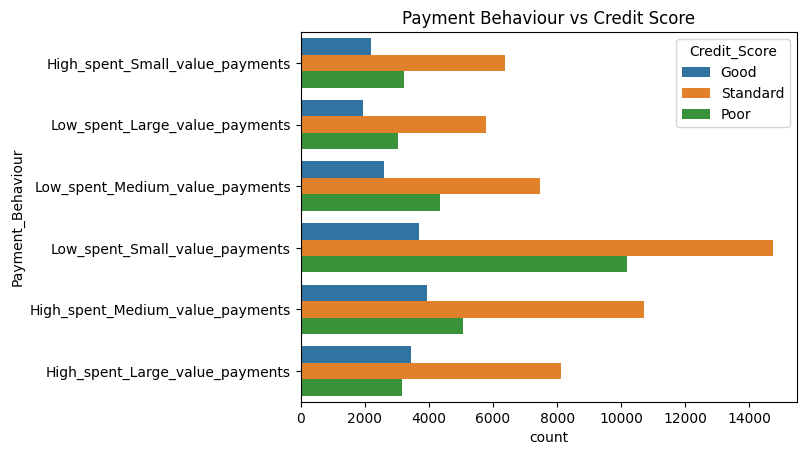

In [28]:
# Chart - 13 visualization code

sns.countplot(y='Payment_Behaviour', hue='Credit_Score', data=df)
plt.title("Payment Behaviour vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?


To analyze behavioral spending patterns.

##### 2. What is/are the insight(s) found from the chart?


- Customers with **high spending + low payment** → Poor score.
- Balanced spending → Good score.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps detect **risky behavioral segments**.

Negative Insight:
- Poor payment habits directly increase default probability.

#### Chart - 14 - Correlation Heatmap

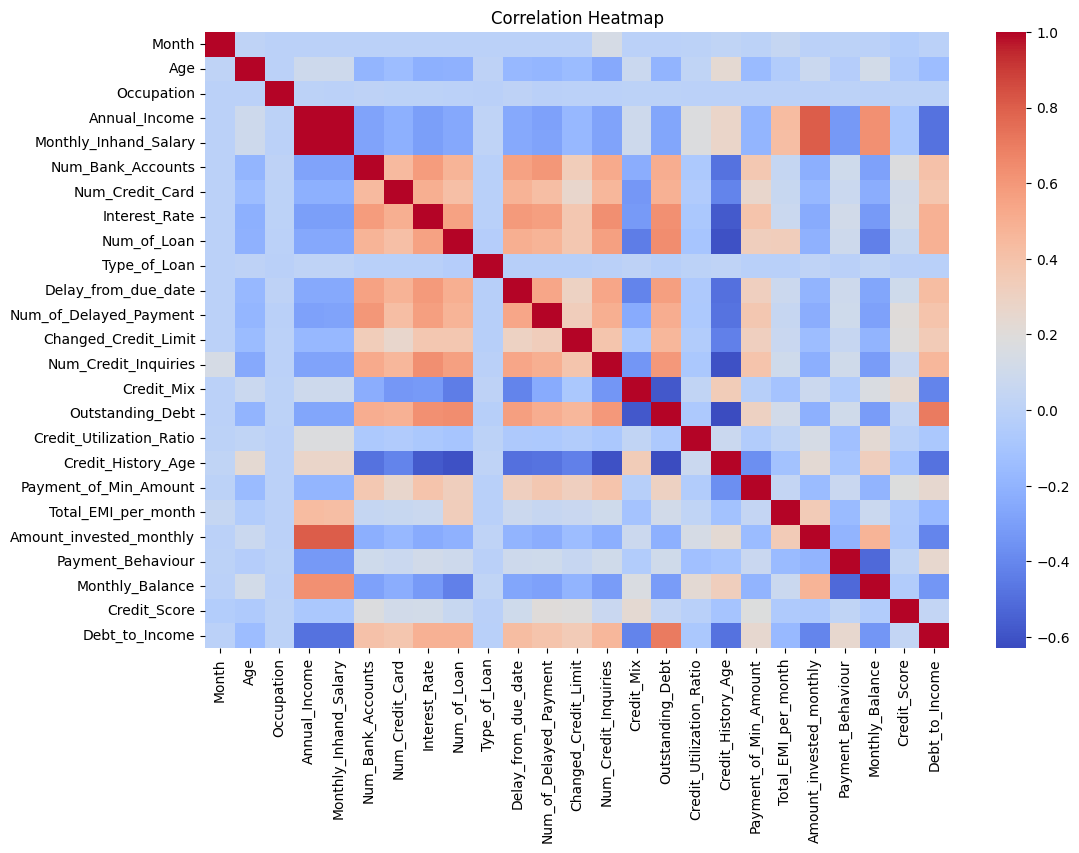

In [29]:
from sklearn.preprocessing import LabelEncoder

# Re-apply Label Encoding to ensure all categorical columns are numerical
# The previous encoding might have been run on an earlier state of df or skipped
le = LabelEncoder() # Initialize LabelEncoder
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Correlation Heatmap visualization code
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?


To identify relationships between numerical variables.

##### 2. What is/are the insight(s) found from the chart?


- Strong correlation between:
  - Debt & EMI  
  - Utilization & Score  
- Some features are redundant.

#### Chart - 15 - Pair Plot

In [36]:
# Pair Plot visualization code
import seaborn as sns # Ensure seaborn is imported
sns.pairplot(df.sample(100), hue='Credit_Score')

Output hidden; open in https://colab.research.google.com to view.

##### 1. Why did you pick the specific chart?


To visualize multivariate relationships.

##### 2. What is/are the insight(s) found from the chart?


- Clear separation between Good and Poor customers.
- Important features: utilization, debt, delay.


#### Chart - 16 - Payment Behaviour vs Score

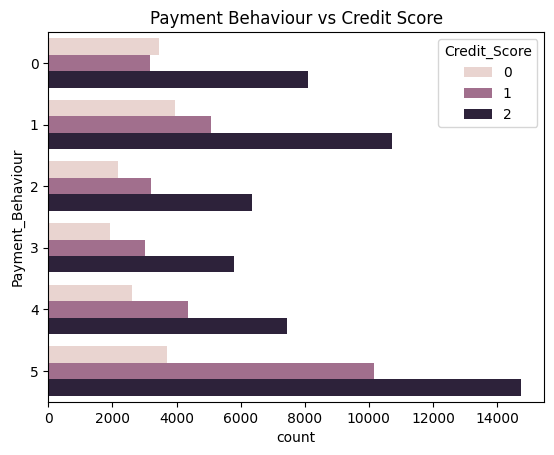

In [31]:
# Chart 16 visualization code
sns.countplot(y='Payment_Behaviour', hue='Credit_Score', data=df)
plt.title("Payment Behaviour vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze how customer spending and payment patterns affect credit score.


##### 2. What is/are the insight(s) found from the chart?

- Customers with **high spending and low payments** fall in Poor category  
- Balanced behavior → Good credit score  


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps identify **risky behavioral segments**  
- Can be used for personalized financial advice  

Negative Insight:
- Irresponsible spending increases default risk

#### Chart - 17 - EMI vs Income

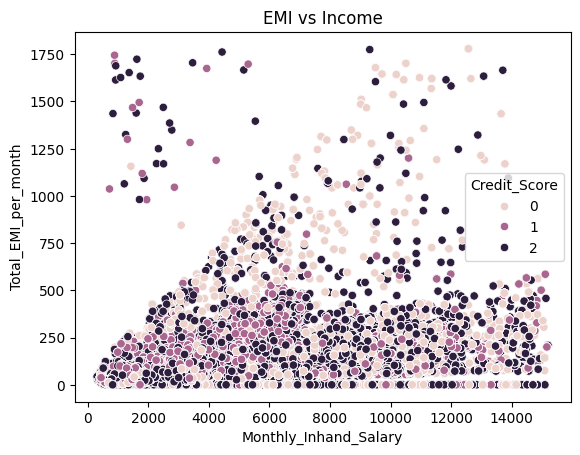

In [32]:
# Chart - 17 visualization code
sns.scatterplot(x='Monthly_Inhand_Salary', y='Total_EMI_per_month', hue='Credit_Score', data=df)
plt.title("EMI vs Income")
plt.show()

##### 1. Why did you pick the specific chart?

To understand financial burden relative to income.

##### 2. What is/are the insight(s) found from the chart?

- High EMI with low income → Poor credit score  
- Balanced EMI → Good score

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps detect financially stressed customers  

Negative Insight:
- Over-leveraged customers → higher risk of default

#### Chart - 18 - Credit  Inquiries

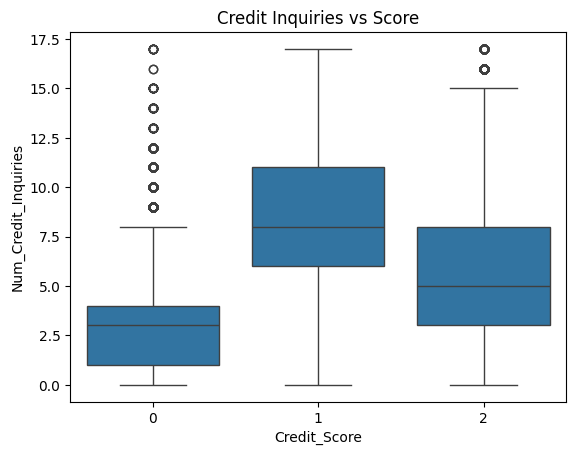

In [33]:
# Chart - 18 visualization code
sns.boxplot(x='Credit_Score', y='Num_Credit_Inquiries', data=df)
plt.title("Credit Inquiries vs Score")
plt.show()

##### 1. Why did you pick the specific chart?


To analyze credit-seeking behavior.

##### 2. What is/are the insight(s) found from the chart?

- More inquiries → Poor credit score  
- Indicates desperate credit seeking  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps flag high-risk customers  

Negative Insight:
- Frequent inquiries signal financial instability

#### Chart - 19 - Loans vs Delay

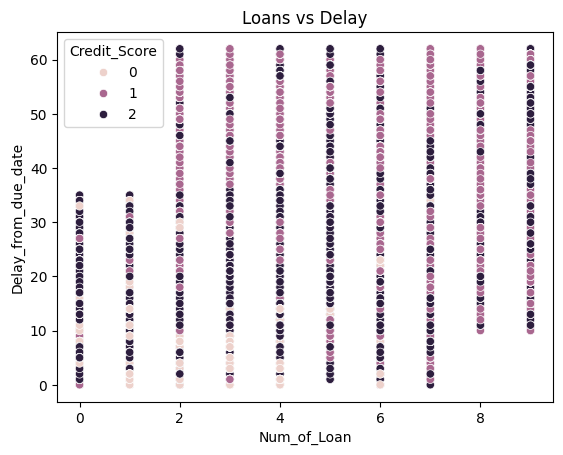

In [34]:
# Chart - 19 visualization code
sns.scatterplot(x='Num_of_Loan', y='Delay_from_due_date', hue='Credit_Score', data=df)
plt.title("Loans vs Delay")
plt.show()

##### 1. Why did you pick the specific chart?

To understand interaction between loan burden and payment delays.

##### 2. What is/are the insight(s) found from the chart?

- More loans + higher delays → Poor credit score  
- Strong combined risk indicator  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps identify **high-risk clusters**  

Negative Insight:
- High loan + delay customers → very high default probability

#### Chart - 20 - Monthly Balance Distribution

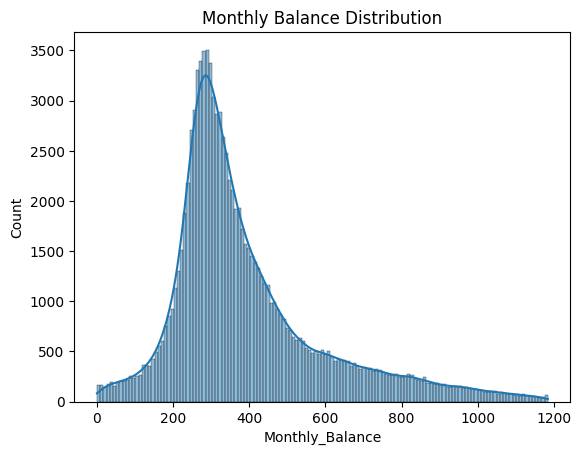

In [35]:
# Chart - 20 visualization code
sns.histplot(df['Monthly_Balance'], kde=True)
plt.title("Monthly Balance Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

To understand financial stability of customers.

##### 2. What is/are the insight(s) found from the chart?


- Many customers have low or negative balances  
- Good credit customers maintain higher balance  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps identify financially stable users  

Negative Insight:
- Low balance customers → liquidity risk

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, the following strategies are recommended for Paisabazaar:

### 1. Risk-Based Customer Segmentation
- Classify customers into risk categories (Low, Medium, High)
- Focus on high-risk customers for stricter loan approvals



### 2. Monitor Credit Utilization
- Flag customers with utilization > 70%
- Encourage optimal usage to improve credit health



### 3. Payment Behavior Tracking
- Identify customers with frequent delays
- Send reminders or penalties for late payments



### 4. Control Loan Exposure
- Limit loans for customers with high EMI burden
- Avoid over-leveraging customers



### 5. Personalized Financial Recommendations
- Suggest investment plans for stable customers
- Provide debt management solutions for risky users



### Final Impact:

- Reduced loan default risk  
- Improved credit decision accuracy  
- Better customer experience  

# **Conclusion**

This project successfully analyzed customer financial behavior to understand the key factors influencing credit scores.

Through comprehensive exploratory data analysis, it was found that credit utilization, payment delays, debt-to-income ratio, and financial behavior are the most significant factors affecting creditworthiness.

The analysis revealed that high-risk customers are characterized by high debt, frequent delays, excessive credit usage, and poor financial discipline. On the other hand, financially stable customers maintain balanced credit usage, timely payments, and lower debt levels.

These insights can help financial institutions like Paisabazaar improve their credit risk assessment process, reduce default rates, and design personalized financial products.

Overall, this project provides valuable business insights that can drive better decision-making and enhance customer segmentation strategies.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***